# Lecture 09 — Unsupervised Learning II: Dimensionality Reduction

**Learning objectives**

- Explain why high-dimensional data are problematic (curse of dimensionality) and why low-dimensional structure is common.
- Derive PCA both as variance maximisation and as minimum reconstruction error, and relate it to the eigendecomposition of the covariance matrix and the SVD of the data matrix.
- Implement PCA from scratch (eigendecomposition and SVD) and verify it against `sklearn.decomposition.PCA`.
- Use explained variance / scree plots to choose the number of components, reconstruct images, and understand whitening.
- Apply kernel PCA to non-linear structure, and use manifold learning methods (t-SNE, MDS, Isomap) — including the caveats of interpreting t-SNE plots.
- Use PCA as a preprocessing step inside a supervised pipeline, tuned by cross-validation.

**Prerequisites**

- Linear algebra: eigenvalues/eigenvectors, SVD, orthogonal projections ([`01_mathematical_foundations.ipynb`](01_mathematical_foundations.ipynb)).
- Lecture 06 ([`06_support_vector_machines.ipynb`](06_support_vector_machines.ipynb)) for kernels, and Lecture 08 ([`08_clustering.ipynb`](08_clustering.ipynb)) for unsupervised learning.

**Contents**

1. Motivation and the curse of dimensionality
2. PCA: two derivations
3. PCA from scratch: eigendecomposition and SVD
4. Explained variance and choosing $k$
5. Reconstructing digit images
6. Whitening
7. Kernel PCA
8. Manifold learning: MDS, Isomap, t-SNE
9. PCA as preprocessing in a pipeline
10. Pitfalls & practical tips
11. Exercises
12. Summary and further reading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, warnings
from sklearn.datasets import load_digits, make_circles, load_breast_cancer
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, MDS, Isomap
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4.5)
np.random.seed(42)
rng = np.random.default_rng(42)

## 1. Motivation and the curse of dimensionality

Dimensionality reduction maps $\mathbf x\in\mathbb R^d$ to $\mathbf z\in\mathbb R^k$ with $k\ll d$ while preserving "what matters". Uses: visualisation ($k=2,3$), compression, denoising, faster/better downstream learning, and discovering latent structure.

**The curse of dimensionality** (Bellman) refers to several counter-intuitive facts about high-dimensional spaces:

- **Volume concentrates near the boundary.** The fraction of a unit hypercube's volume within distance $\epsilon$ of its surface is $1-(1-2\epsilon)^d\to1$. To capture a fraction $r$ of uniformly distributed data with a sub-cube you need edge length $r^{1/d}$ — for $d=100$, capturing 1% of the data needs edge $0.01^{1/100}\approx0.955$. "Local" neighbourhoods are not local.
- **Distances concentrate.** For i.i.d. coordinates, $\lVert\mathbf x-\mathbf y\rVert^2$ is a sum of $d$ independent terms, so its mean grows like $d$ while its standard deviation grows like $\sqrt d$: the relative contrast $(\text{max dist}-\text{min dist})/\text{min dist}\to0$. Nearest neighbours become barely nearer than the farthest points.
- **Sample complexity explodes.** Covering $[0,1]^d$ at resolution $\epsilon$ requires $\epsilon^{-d}$ points.

Fortunately, real data usually lie near a **low-dimensional manifold** (the *manifold hypothesis*): $8\times8$ digit images live in $\mathbb R^{64}$, but plausible digits occupy a tiny, highly structured subset.

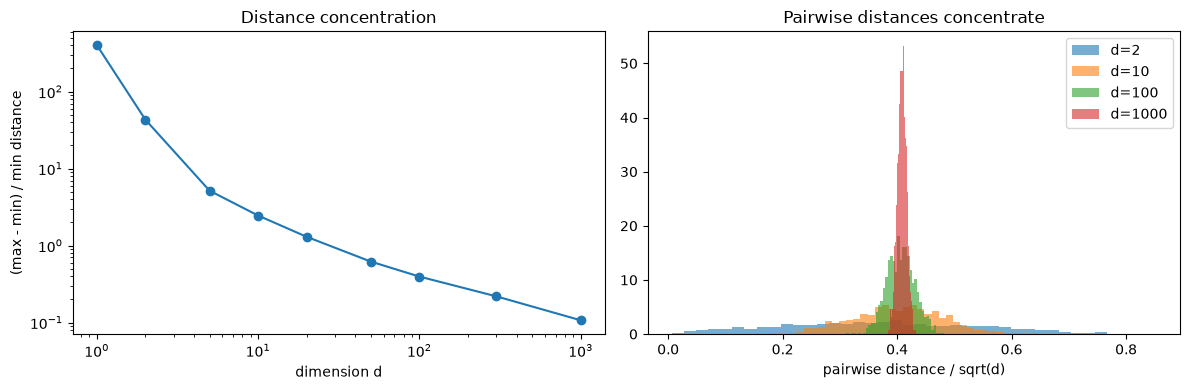

In [2]:
# Distance concentration: relative contrast of distances from a query point to n random points
n = 500
dims = [1, 2, 5, 10, 20, 50, 100, 300, 1000]
contrast = []
for d in dims:
    P = rng.uniform(size=(n, d)); q = rng.uniform(size=d)
    dist = np.linalg.norm(P - q, axis=1)
    contrast.append((dist.max() - dist.min()) / dist.min())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].loglog(dims, contrast, "o-"); axes[0].set_xlabel("dimension d")
axes[0].set_ylabel("(max - min) / min distance"); axes[0].set_title("Distance concentration")
for d in [2, 10, 100, 1000]:
    P = rng.uniform(size=(2000, d))
    dd = np.linalg.norm(P[:1000] - P[1000:], axis=1)
    axes[1].hist(dd / np.sqrt(d), bins=40, density=True, alpha=0.6, label=f"d={d}")
axes[1].set_xlabel("pairwise distance / sqrt(d)"); axes[1].set_title("Pairwise distances concentrate"); axes[1].legend()
plt.tight_layout(); plt.show()

## 2. PCA: two derivations

Let $X\in\mathbb R^{n\times d}$ be the **centred** data matrix (rows $\mathbf x_i^\top$, column means zero) and $S=\frac1nX^\top X$ the sample covariance (use $\frac1{n-1}$ for the unbiased version; it only rescales eigenvalues).

### 2.1 Maximum variance

Find the unit direction $\mathbf u$ along which the projected data $\mathbf u^\top\mathbf x_i$ have maximal variance:
$$
\max_{\mathbf u}\;\frac1n\sum_i(\mathbf u^\top\mathbf x_i)^2=\mathbf u^\top S\mathbf u\quad\text{s.t.}\quad\mathbf u^\top\mathbf u=1 .
$$
Lagrangian: $\mathbf u^\top S\mathbf u-\lambda(\mathbf u^\top\mathbf u-1)$; setting the gradient to zero gives $S\mathbf u=\lambda\mathbf u$. So $\mathbf u$ is an **eigenvector** of $S$, and the attained variance is $\mathbf u^\top S\mathbf u=\lambda$: choose the **largest** eigenvalue. The second component maximises variance subject to orthogonality to the first, giving the second eigenvector, and so on (by induction, or via the Courant–Fischer theorem). With $U_k=[\mathbf u_1,\dots,\mathbf u_k]$, the projected variance is $\operatorname{tr}(U_k^\top SU_k)=\sum_{j\le k}\lambda_j$.

### 2.2 Minimum reconstruction error

Find an orthonormal $U_k\in\mathbb R^{d\times k}$ minimising the squared error of the orthogonal projection $\hat{\mathbf x}_i=U_kU_k^\top\mathbf x_i$:
$$
\min_{U_k^\top U_k=I}\;\frac1n\sum_i\lVert\mathbf x_i-U_kU_k^\top\mathbf x_i\rVert^2 .
$$
Since $P=U_kU_k^\top$ is an orthogonal projector ($P^2=P=P^\top$), Pythagoras gives $\lVert\mathbf x\rVert^2=\lVert P\mathbf x\rVert^2+\lVert\mathbf x-P\mathbf x\rVert^2$. Therefore
$$
\frac1n\sum_i\lVert\mathbf x_i-P\mathbf x_i\rVert^2=\operatorname{tr}(S)-\operatorname{tr}(U_k^\top SU_k),
$$
and **minimising reconstruction error is exactly maximising projected variance**. The minimum is $\sum_{j>k}\lambda_j$ — the sum of the discarded eigenvalues. (Eckart–Young: the rank-$k$ truncated SVD is the best rank-$k$ approximation of $X$ in Frobenius norm.)

### 2.3 Connection to the SVD

Write the thin SVD $X=V_L\Sigma W^\top$ (left singular vectors $V_L\in\mathbb R^{n\times r}$, singular values $\sigma_1\ge\dots\ge0$, right singular vectors $W\in\mathbb R^{d\times r}$). Then
$$
S=\frac1nX^\top X=W\frac{\Sigma^2}{n}W^\top ,
$$
so the principal directions are the right singular vectors, $\lambda_j=\sigma_j^2/n$, and the scores are $Z=XW_k=V_{L,k}\Sigma_k$. The SVD route avoids forming $X^\top X$, which **squares the condition number** and loses precision; it costs $O(nd\min(n,d))$. For large data, randomised SVD (Halko et al., 2011) computes the top $k$ components in $O(ndk)$.

### 2.4 Probabilistic view (brief)

Probabilistic PCA (Tipping & Bishop, 1999): $\mathbf z\sim\mathcal N(0,I_k)$, $\mathbf x=W\mathbf z+\boldsymbol\mu+\boldsymbol\epsilon$, $\boldsymbol\epsilon\sim\mathcal N(0,\sigma^2I)$. The MLE of $W$ spans the top-$k$ eigenvectors, and $\sigma^2_{\text{ML}}$ is the average discarded eigenvalue. This gives a likelihood (for model selection) and connects PCA to factor analysis and linear-Gaussian latent variable models.

## 3. PCA from scratch: eigendecomposition and SVD

We implement both routes and check them against sklearn. Principal directions are only defined up to sign, so we fix a sign convention (largest-magnitude loading positive) before comparing.

In [3]:
class PCAScratch:
    def __init__(self, n_components, method="svd"):
        self.n_components, self.method = n_components, method

    @staticmethod
    def _fix_signs(W):
        # make the largest-|.| entry of each component positive (sign is arbitrary)
        idx = np.abs(W).argmax(0)
        return W * np.sign(W[idx, np.arange(W.shape[1])])

    def fit(self, X):
        n, d = X.shape
        self.mean_ = X.mean(0)
        Xc = X - self.mean_                                   # centre the data
        if self.method == "eig":
            S = Xc.T @ Xc / (n - 1)                           # sample covariance (d x d)
            evals, evecs = np.linalg.eigh(S)                  # ascending order for symmetric matrices
            order = np.argsort(evals)[::-1]
            evals, evecs = evals[order], evecs[:, order]
        else:
            _, s, Wt = np.linalg.svd(Xc, full_matrices=False) # Xc = U diag(s) W^T
            evals, evecs = s ** 2 / (n - 1), Wt.T
        k = self.n_components
        self.components_ = self._fix_signs(evecs[:, :k]).T    # (k, d), rows = directions
        self.explained_variance_ = evals[:k]
        self.explained_variance_ratio_ = evals[:k] / evals.sum()
        return self

    def transform(self, X):
        return (X - self.mean_) @ self.components_.T          # scores z = W_k^T (x - mean)

    def inverse_transform(self, Z):
        return Z @ self.components_ + self.mean_              # reconstruction x_hat = W_k z + mean

In [4]:
digits = load_digits()
Xd, yd = digits.data, digits.target
k = 10
p_eig = PCAScratch(k, "eig").fit(Xd)
p_svd = PCAScratch(k, "svd").fit(Xd)
p_sk = PCA(k, svd_solver="full").fit(Xd)
W_sk = PCAScratch._fix_signs(p_sk.components_.T).T

print("max |components eig - svd|     :", np.abs(p_eig.components_ - p_svd.components_).max())
print("max |components svd - sklearn| :", np.abs(p_svd.components_ - W_sk).max())
print("max |explained var svd - sklearn|:", np.abs(p_svd.explained_variance_ - p_sk.explained_variance_).max())
print("explained variance ratio (first 5):", p_svd.explained_variance_ratio_[:5].round(4))
Z = p_svd.transform(Xd)
print("scores are uncorrelated: max |off-diagonal of cov(Z)| =",
      np.abs(np.cov(Z.T) - np.diag(np.diag(np.cov(Z.T)))).max().round(10))

max |components eig - svd|     : 5.322131624296844e-15
max |components svd - sklearn| : 0.0
max |explained var svd - sklearn|: 0.0
explained variance ratio (first 5): [0.1489 0.1362 0.1179 0.0841 0.0578]
scores are uncorrelated: max |off-diagonal of cov(Z)| = 0.0


All three agree to numerical precision, and the scores are uncorrelated (the covariance of $Z$ is $\operatorname{diag}(\lambda_1,\dots,\lambda_k)$) — PCA **decorrelates** the data.

### 3.1 Numerical stability: why prefer the SVD

Forming $X^\top X$ squares the singular values. When the data contain directions with tiny variance relative to the largest, those eigenvalues fall below machine precision relative to $\lambda_1$ and are lost. A small example (Läuchli-type matrix):

In [5]:
eps = 1e-9
Xl = np.array([[1, 1], [eps, 0], [0, eps]], dtype=float)
sv = np.linalg.svd(Xl, compute_uv=False)
ev = np.sort(np.linalg.eigvalsh(Xl.T @ Xl))[::-1]
print("singular values via SVD           :", sv)
print("sqrt(eigenvalues of X^T X)        :", np.sqrt(np.maximum(ev, 0)))
print("exact smallest singular value     :", eps)

singular values via SVD           : [1.41421356e+00 1.00000000e-09]
sqrt(eigenvalues of X^T X)        : [1.41421356 0.        ]
exact smallest singular value     : 1e-09


## 4. Explained variance and choosing $k$

The fraction of variance explained by the first $k$ components is $\sum_{j\le k}\lambda_j/\sum_j\lambda_j$. Common rules for choosing $k$:

- keep enough components to explain e.g. 90–95% of the variance (`PCA(n_components=0.95)`);
- look for an elbow in the **scree plot** of $\lambda_j$;
- Kaiser rule (on standardised data): keep components with $\lambda_j>1$ — crude;
- choose $k$ by cross-validating a downstream task (Section 9), or by PPCA likelihood / Minka's MLE (`n_components="mle"`).

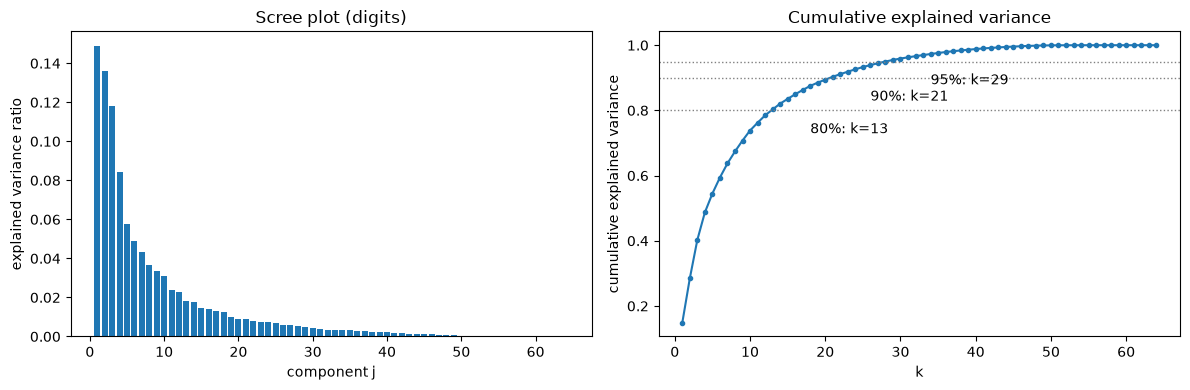

In [6]:
pca_full = PCA().fit(Xd)
cum = np.cumsum(pca_full.explained_variance_ratio_)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, 65), pca_full.explained_variance_ratio_); axes[0].set_xlabel("component j")
axes[0].set_ylabel("explained variance ratio"); axes[0].set_title("Scree plot (digits)")
axes[1].plot(range(1, 65), cum, "o-", ms=3)
for thr in [0.8, 0.9, 0.95]:
    kk = np.searchsorted(cum, thr) + 1
    axes[1].axhline(thr, color="gray", ls=":", lw=1); axes[1].annotate(f"{thr:.0%}: k={kk}", (kk, thr), (kk + 5, thr - 0.07))
axes[1].set_xlabel("k"); axes[1].set_ylabel("cumulative explained variance"); axes[1].set_title("Cumulative explained variance")
plt.tight_layout(); plt.show()

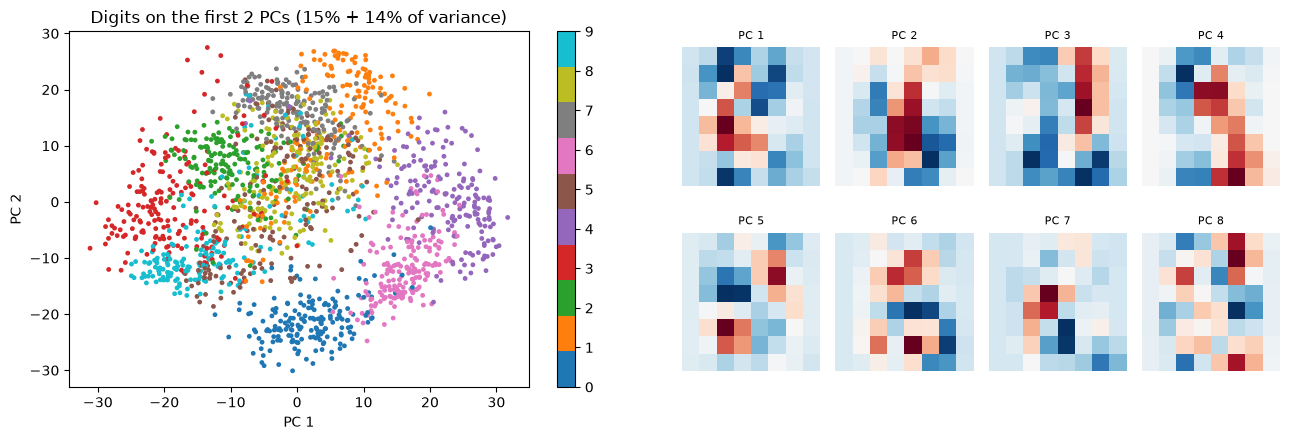

In [7]:
# First two principal components and the first principal directions viewed as images
fig = plt.figure(figsize=(13, 4.5))
ax = fig.add_subplot(1, 2, 1)
Z2 = PCA(2).fit_transform(Xd)
sc = ax.scatter(Z2[:, 0], Z2[:, 1], c=yd, cmap="tab10", s=6)
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); evr2 = pca_full.explained_variance_ratio_[:2]
ax.set_title(f"Digits on the first 2 PCs ({evr2[0]:.0%} + {evr2[1]:.0%} of variance)")
plt.colorbar(sc, ax=ax, ticks=range(10))
for j in range(8):
    a = fig.add_subplot(2, 8, 5 + (j // 4) * 8 + j % 4)
    a.imshow(pca_full.components_[j].reshape(8, 8), cmap="RdBu_r"); a.set_title(f"PC {j + 1}", fontsize=8); a.axis("off")
plt.tight_layout(); plt.show()

Two linear components already separate some digits (0, 4, 6) but leave many overlapping — the structure is non-linear and spread across many directions. The principal directions ("eigendigits") are contrast patterns of pixels.

## 5. Reconstructing digit images

The reconstruction from $k$ components is $\hat{\mathbf x}=\bar{\mathbf x}+\sum_{j\le k}z_j\mathbf u_j$, and the mean squared reconstruction error equals the sum of discarded eigenvalues (with the $1/n$ covariance convention; $\frac{n-1}{n}\sum_{j>k}\lambda_j$ with sklearn's $1/(n-1)$). We verify this identity and look at the images.

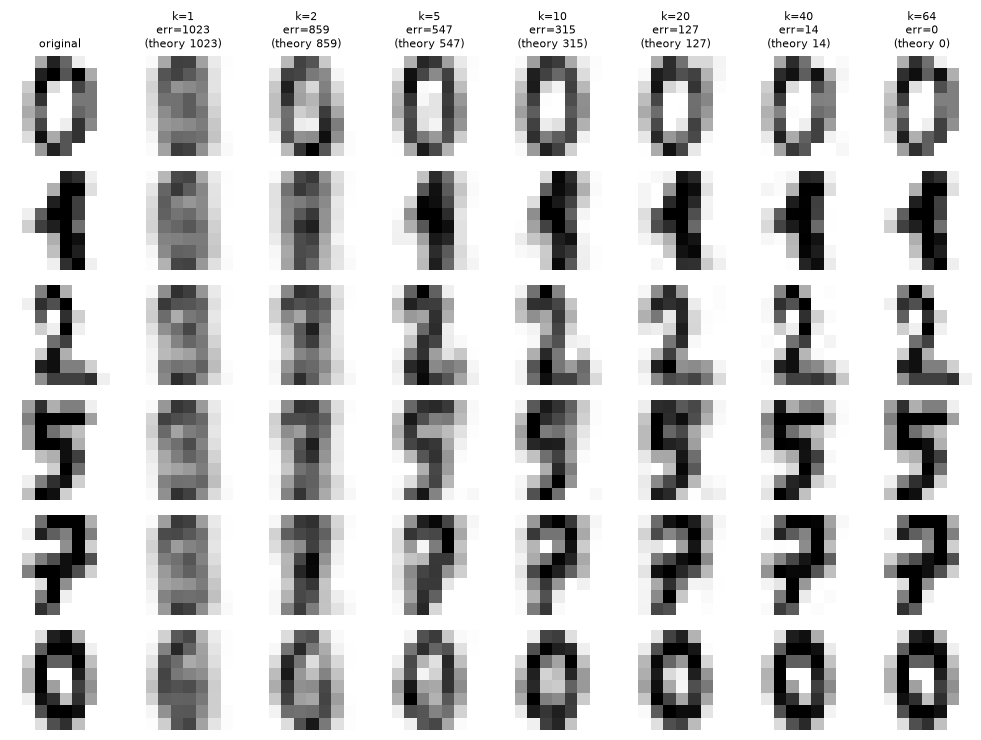

In [8]:
ks = [1, 2, 5, 10, 20, 40, 64]
idx = [0, 11, 22, 33, 44, 55]
n = len(Xd)
fig, axes = plt.subplots(len(idx), len(ks) + 1, figsize=(10, 7.5))
for c, k in enumerate(ks):
    p = PCAScratch(k).fit(Xd)
    Xhat = p.inverse_transform(p.transform(Xd))
    mse = ((Xd - Xhat) ** 2).sum(1).mean()
    theory = pca_full.explained_variance_[k:].sum() * (n - 1) / n
    for r, i in enumerate(idx):
        axes[r, c + 1].imshow(Xhat[i].reshape(8, 8), cmap="gray_r", vmin=0, vmax=16); axes[r, c + 1].axis("off")
    axes[0, c + 1].set_title(f"k={k}\nerr={mse:.0f}\n(theory {theory:.0f})", fontsize=8)
for r, i in enumerate(idx):
    axes[r, 0].imshow(Xd[i].reshape(8, 8), cmap="gray_r"); axes[r, 0].axis("off")
axes[0, 0].set_title("original", fontsize=8)
plt.tight_layout(); plt.show()

With about 20 of 64 components the digits are clearly recognisable — a compression ratio of about 3 (plus the shared basis). Reconstruction from a few components also acts as **denoising**: noise spread evenly over all directions is mostly discarded along with the low-variance components.

components kept: 12   MSE noisy vs clean: 15.96   denoised vs clean: 7.25


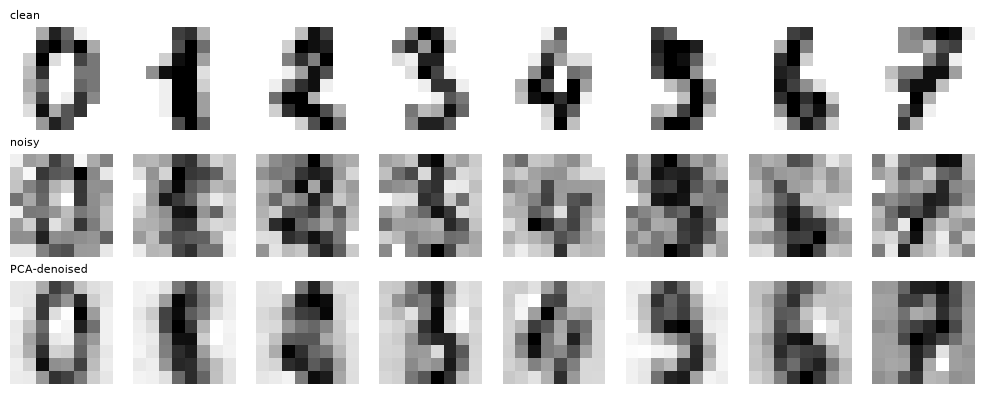

In [9]:
Xnoisy = Xd + rng.normal(0, 4, Xd.shape)
p_dn = PCA(n_components=0.5).fit(Xnoisy)            # keep 50% of the (noisy) variance
Xden = p_dn.inverse_transform(p_dn.transform(Xnoisy))
print(f"components kept: {p_dn.n_components_}   MSE noisy vs clean: {((Xnoisy - Xd) ** 2).mean():.2f}   "
      f"denoised vs clean: {((Xden - Xd) ** 2).mean():.2f}")
fig, axes = plt.subplots(3, 8, figsize=(10, 4))
for j in range(8):
    for r, (img, name) in enumerate([(Xd, "clean"), (Xnoisy, "noisy"), (Xden, "PCA-denoised")]):
        axes[r, j].imshow(img[j].reshape(8, 8), cmap="gray_r"); axes[r, j].axis("off")
        if j == 0: axes[r, j].set_title(name, fontsize=8, loc="left")
plt.tight_layout(); plt.show()

## 6. Whitening

**Whitening** rescales the scores to unit variance: $\mathbf z_{\text{white}}=\Lambda_k^{-1/2}U_k^\top(\mathbf x-\bar{\mathbf x})$, so that $\operatorname{Cov}(\mathbf z_{\text{white}})=I$. (ZCA whitening additionally rotates back, $U\Lambda^{-1/2}U^\top(\mathbf x-\bar{\mathbf x})$, staying as close as possible to the original coordinates.)

- Useful when a downstream method assumes isotropic, decorrelated inputs (e.g. ICA, some distance-based methods).
- Caution: it **amplifies low-variance directions**, which are often noise — whiten only on the retained top components, or add a small $\epsilon$: $(\Lambda+\epsilon I)^{-1/2}$.
- Whitened data lose the relative importance information encoded in the variances, which can hurt models that benefit from it.

cov of whitened scores (scratch):
 [[1. 0.]
 [0. 1.]]
sklearn whiten=True agrees up to sign: True


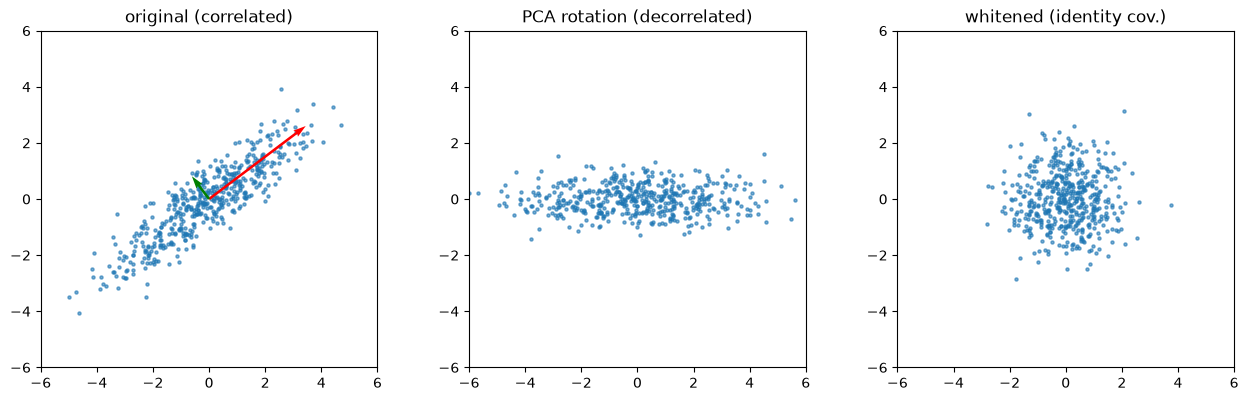

In [10]:
C2 = np.array([[3.0, 2.2], [2.2, 2.0]])
X2 = rng.multivariate_normal([0, 0], C2, size=500)
p2 = PCAScratch(2).fit(X2)
Zs = p2.transform(X2)                                   # rotated (decorrelated)
Zw = Zs / np.sqrt(p2.explained_variance_)               # whitened: unit variance
Zw_sk = PCA(2, whiten=True).fit_transform(X2)
print("cov of whitened scores (scratch):\n", np.cov(Zw.T).round(3))
print("sklearn whiten=True agrees up to sign:", np.allclose(np.abs(Zw), np.abs(Zw_sk)))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, D, t in zip(axes, [X2, Zs, Zw], ["original (correlated)", "PCA rotation (decorrelated)", "whitened (identity cov.)"]):
    ax.scatter(D[:, 0], D[:, 1], s=5, alpha=0.6); ax.set_aspect("equal"); ax.set_xlim(-6, 6); ax.set_ylim(-6, 6); ax.set_title(t)
axes[0].quiver([0, 0], [0, 0], *(p2.components_.T * 2 * np.sqrt(p2.explained_variance_)), angles="xy",
               scale_units="xy", scale=1, color=["r", "g"])
plt.tight_layout(); plt.show()

## 7. Kernel PCA

PCA only finds **linear** subspaces. Kernel PCA (Schölkopf, Smola & Müller, 1998) performs PCA in a feature space $\phi(\mathbf x)$ defined implicitly by a kernel (Lecture 06).

Derivation sketch: eigenvectors of the feature-space covariance $C=\frac1n\sum_i\phi(\mathbf x_i)\phi(\mathbf x_i)^\top$ lie in the span of the data, $\mathbf v=\sum_i a_i\phi(\mathbf x_i)$. Substituting into $C\mathbf v=\lambda\mathbf v$ and taking inner products with each $\phi(\mathbf x_l)$ gives
$$
K\mathbf a=n\lambda\,\mathbf a,\qquad K_{ij}=k(\mathbf x_i,\mathbf x_j).
$$
Normalising $\lVert\mathbf v\rVert=1$ requires $\mathbf a^\top K\mathbf a=1$, i.e. $\lVert\mathbf a\rVert^2=1/\mu$ for eigenvalue $\mu$ of $K$. The projection of a point is $\langle\mathbf v,\phi(\mathbf x)\rangle=\sum_ia_ik(\mathbf x_i,\mathbf x)$. Centring in feature space is done on the kernel matrix: $\tilde K=K-\mathbf 1_nK-K\mathbf 1_n+\mathbf 1_nK\mathbf 1_n$ with $(\mathbf 1_n)_{ij}=1/n$.

Cost: $O(n^2)$ memory and $O(n^3)$ eigendecomposition; there is no exact pre-image (reconstruction) in general.

scratch vs sklearn KernelPCA (up to sign): max abs diff = 0.0


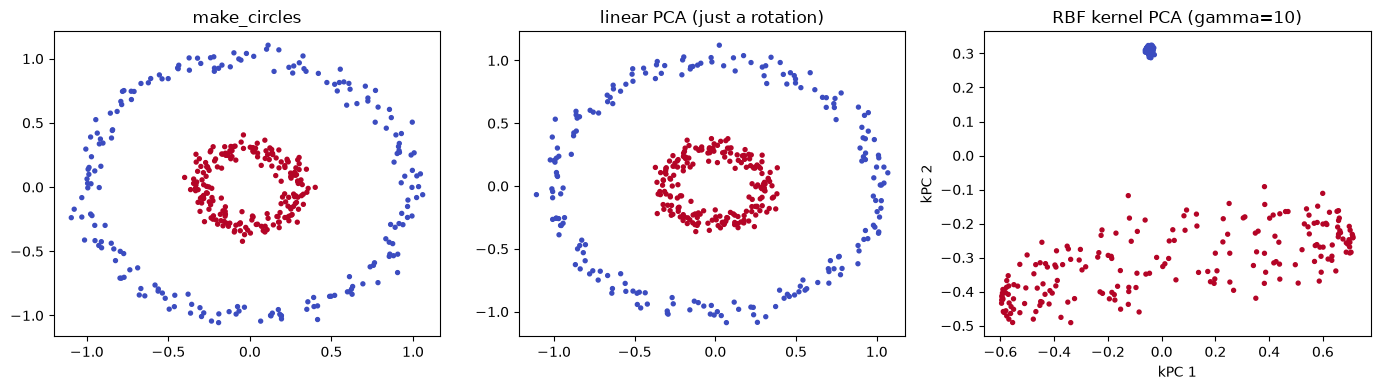

In [11]:
def kernel_pca_scratch(X, n_components=2, gamma=10.0):
    sq = (X ** 2).sum(1)
    K = np.exp(-gamma * (sq[:, None] + sq[None, :] - 2 * X @ X.T))     # RBF kernel matrix
    n = len(X)
    one = np.full((n, n), 1 / n)
    Kc = K - one @ K - K @ one + one @ K @ one                           # centre in feature space
    mu, A_ = np.linalg.eigh(Kc)
    mu, A_ = mu[::-1][:n_components], A_[:, ::-1][:, :n_components]
    A_ = A_ / np.sqrt(mu)                                                # normalise so ||v|| = 1
    return Kc @ A_                                                       # projections of training points

Xc, yc = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=0)
Zk = kernel_pca_scratch(Xc, 2, gamma=10)
Zk_sk = KernelPCA(2, kernel="rbf", gamma=10).fit_transform(Xc)
print("scratch vs sklearn KernelPCA (up to sign): max abs diff =",
      np.abs(np.abs(Zk) - np.abs(Zk_sk)).max().round(8))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", s=8); axes[0].set_title("make_circles")
Zl = PCA(2).fit_transform(Xc)
axes[1].scatter(Zl[:, 0], Zl[:, 1], c=yc, cmap="coolwarm", s=8); axes[1].set_title("linear PCA (just a rotation)")
axes[2].scatter(Zk[:, 0], Zk[:, 1], c=yc, cmap="coolwarm", s=8); axes[2].set_title("RBF kernel PCA (gamma=10)")
axes[2].set_xlabel("kPC 1"); axes[2].set_ylabel("kPC 2")
plt.tight_layout(); plt.show()

In kernel PCA space the two circles become linearly separable along the first component. The result depends strongly on $\gamma$ — too small behaves like linear PCA, too large makes every point its own island:

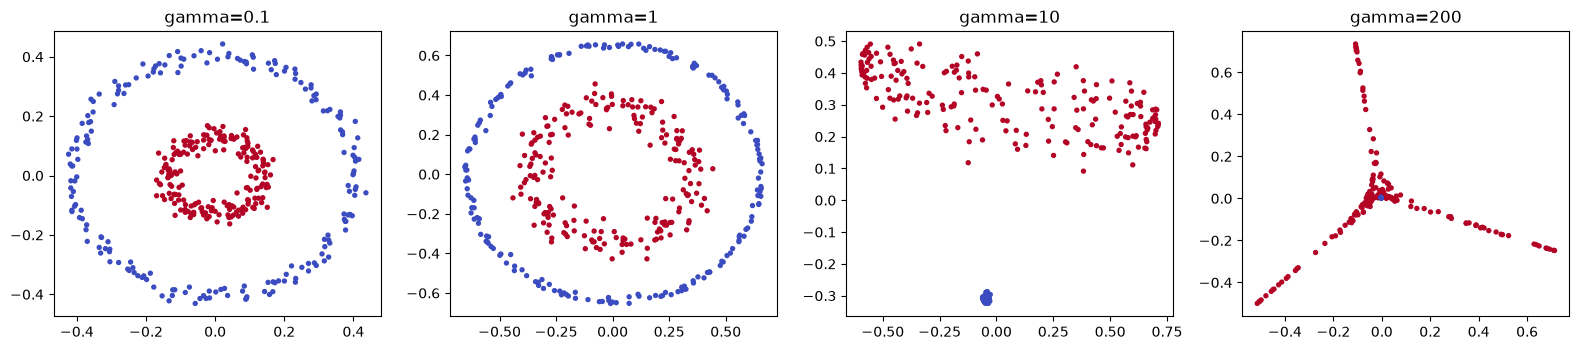

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, g in zip(axes, [0.1, 1, 10, 200]):
    Z_ = KernelPCA(2, kernel="rbf", gamma=g).fit_transform(Xc)
    ax.scatter(Z_[:, 0], Z_[:, 1], c=yc, cmap="coolwarm", s=8); ax.set_title(f"gamma={g}")
plt.tight_layout(); plt.show()

## 8. Manifold learning: MDS, Isomap, t-SNE

Non-linear embedding methods try to place points $\mathbf y_i\in\mathbb R^2$ so that some notion of *neighbourhood* or *distance* in the original space is preserved.

- **Classical / metric MDS** finds $\mathbf y_i$ whose Euclidean distances match given dissimilarities $\delta_{ij}$: minimise the *stress* $\sum_{i<j}(\lVert\mathbf y_i-\mathbf y_j\rVert-\delta_{ij})^2$. With Euclidean $\delta$, classical MDS is equivalent to PCA.
- **Isomap** (Tenenbaum et al., 2000): build a $k$-NN graph, approximate **geodesic** distances along the manifold by shortest paths, then apply classical MDS. Unrolls "Swiss rolls" but is sensitive to short-circuit edges.
- **t-SNE** (van der Maaten & Hinton, 2008): convert distances to neighbour probabilities $p_{j|i}\propto\exp(-\lVert\mathbf x_i-\mathbf x_j\rVert^2/2\sigma_i^2)$, with $\sigma_i$ set so that each conditional distribution has a user-chosen **perplexity** ($2^{H(P_i)}$, an effective number of neighbours), and symmetrise $p_{ij}=(p_{j|i}+p_{i|j})/2n$. In the embedding use a heavy-tailed Student-t kernel $q_{ij}\propto(1+\lVert\mathbf y_i-\mathbf y_j\rVert^2)^{-1}$ and minimise
$$
\mathrm{KL}(P\,\|\,Q)=\sum_{i\ne j}p_{ij}\log\frac{p_{ij}}{q_{ij}},\qquad
\frac{\partial\,\mathrm{KL}}{\partial\mathbf y_i}=4\sum_j(p_{ij}-q_{ij})(\mathbf y_i-\mathbf y_j)(1+\lVert\mathbf y_i-\mathbf y_j\rVert^2)^{-1}.
$$
The KL penalises placing true neighbours far apart heavily, but barely penalises placing distant points close — t-SNE preserves **local** structure. The heavy tails counteract the "crowding problem" (there is not enough room in 2-D to keep all moderate distances). Barnes–Hut approximation gives $O(n\log n)$ per iteration.

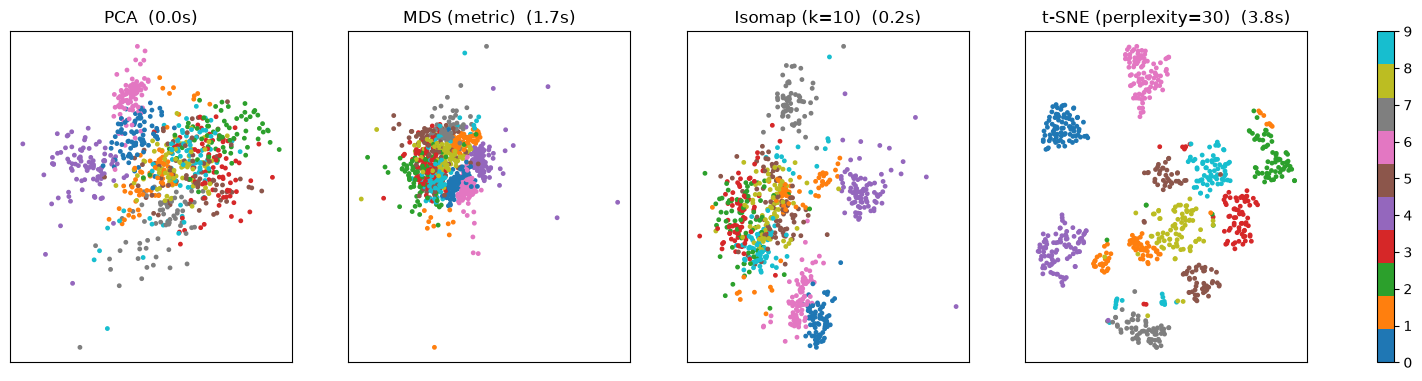

In [13]:
# Subsample the digits to keep MDS (O(n^2) per iteration) fast
sub = rng.choice(len(Xd), 800, replace=False)
Xs, ys = StandardScaler().fit_transform(Xd[sub]), yd[sub]
embeds, times = {}, {}
for name, est in [("PCA", PCA(2)),
                  ("MDS (metric)", MDS(2, n_init=1, max_iter=200, init="classical_mds", random_state=0)),
                  ("Isomap (k=10)", Isomap(n_neighbors=10, n_components=2)),
                  ("t-SNE (perplexity=30)", TSNE(2, perplexity=30, init="pca", random_state=0))]:
    t0 = time.perf_counter(); embeds[name] = est.fit_transform(Xs); times[name] = time.perf_counter() - t0

fig, axes = plt.subplots(1, 4, figsize=(18, 4.3))
for ax, (name, E) in zip(axes, embeds.items()):
    sc = ax.scatter(E[:, 0], E[:, 1], c=ys, cmap="tab10", s=6)
    ax.set_title(f"{name}  ({times[name]:.1f}s)"); ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(sc, ax=axes, ticks=range(10), fraction=0.02)
plt.show()

### 8.1 How (not) to read a t-SNE plot

t-SNE produces striking pictures, but many visual features are **artefacts** (Wattenberg, Viégas & Johnson, 2016):

- **Cluster sizes mean nothing**: t-SNE equalises local densities, so a tight and a diffuse cluster can look the same size.
- **Distances between clusters mean little**: global geometry is not preserved; clusters that look far apart may not be.
- **Perplexity matters**: small values show spurious fine structure, large ones merge clusters. Always look at several.
- **Random noise can look clustered** at low perplexity.
- **It is stochastic and non-convex**: different seeds give different layouts; PCA initialisation improves stability.
- **There is no `transform` for new points**: t-SNE is a visualisation tool, not a feature extractor for downstream models. (UMAP, not available here, is a popular faster alternative with similar caveats.)

We illustrate two of these: perplexity dependence, and structure hallucinated from pure Gaussian noise.

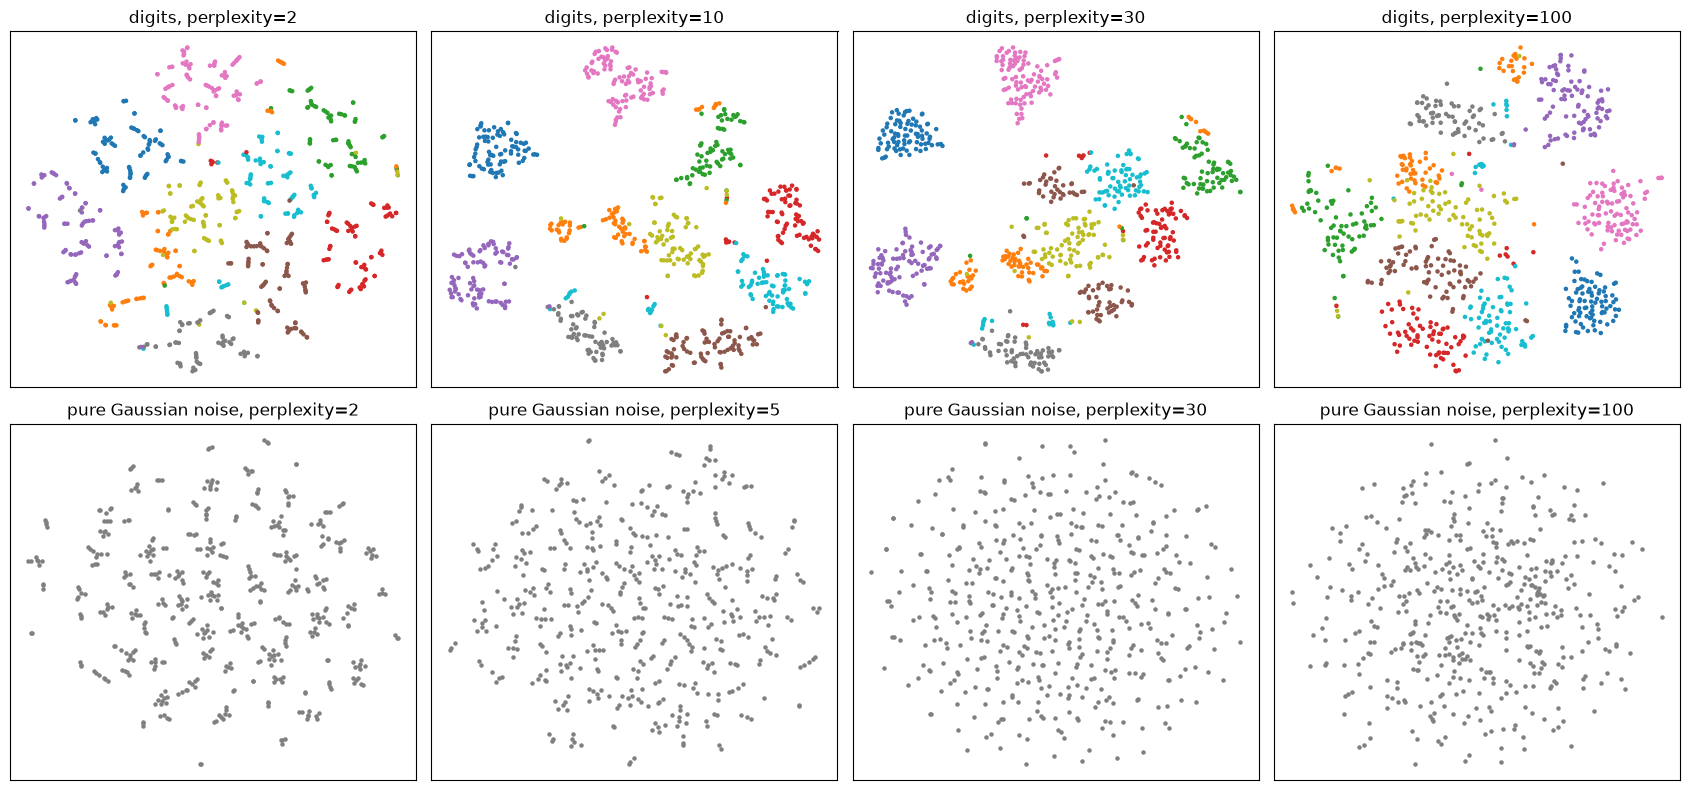

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, perp in zip(axes[0], [2, 10, 30, 100]):
    E = TSNE(2, perplexity=perp, init="pca", random_state=0).fit_transform(Xs)
    ax.scatter(E[:, 0], E[:, 1], c=ys, cmap="tab10", s=5); ax.set_title(f"digits, perplexity={perp}")
    ax.set_xticks([]); ax.set_yticks([])
noise = rng.normal(size=(500, 50))                      # structureless isotropic Gaussian data
for ax, perp in zip(axes[1], [2, 5, 30, 100]):
    E = TSNE(2, perplexity=perp, init="pca", random_state=0).fit_transform(noise)
    ax.scatter(E[:, 0], E[:, 1], s=5, c="gray"); ax.set_title(f"pure Gaussian noise, perplexity={perp}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

At perplexity 2 the digits shatter into many small fragments, and even pure noise shows apparent "clumps". A quantitative check is to measure **neighbourhood preservation** — e.g. `sklearn.manifold.trustworthiness`, the extent to which the embedding's $k$ nearest neighbours were also near in the original space:

In [15]:
from sklearn.manifold import trustworthiness
rows = [{"method": name, "trustworthiness (k=10)": trustworthiness(Xs, E, n_neighbors=10),
         "kNN acc. in 2-D (5-fold CV)": cross_val_score(KNeighborsClassifier(5), E, ys, cv=5).mean()}
        for name, E in embeds.items()]
pd.DataFrame(rows).set_index("method").round(3)

,trustworthiness (k=10),kNN acc. in 2-D (5-fold CV)
method,,
PCA,0.822,0.579
MDS (metric),0.883,0.698
Isomap (k=10),0.859,0.684
t-SNE (perplexity=30),0.976,0.962


t-SNE preserves local neighbourhoods best (and a $k$-NN classifier in its 2-D map is very accurate), whereas the 2-D PCA projection is much less faithful locally. But beware: the kNN accuracy here is computed on an embedding fitted with *all* points, so it is an optimistic, transductive measure, not a valid estimate of generalisation.

## 9. PCA as preprocessing in a pipeline

PCA before a supervised model can reduce noise and computation, and mitigate collinearity. Rules:

1. Fit PCA **inside the cross-validation loop** (in a `Pipeline`) to avoid leakage.
2. **Standardise first** if features have different units — PCA is driven by variance, so large-scale features dominate otherwise.
3. Treat $k$ as a hyperparameter; PCA is **unsupervised**, so the top-variance directions are not guaranteed to be the most predictive (a low-variance direction may carry all the signal — then PLS or supervised methods are better).

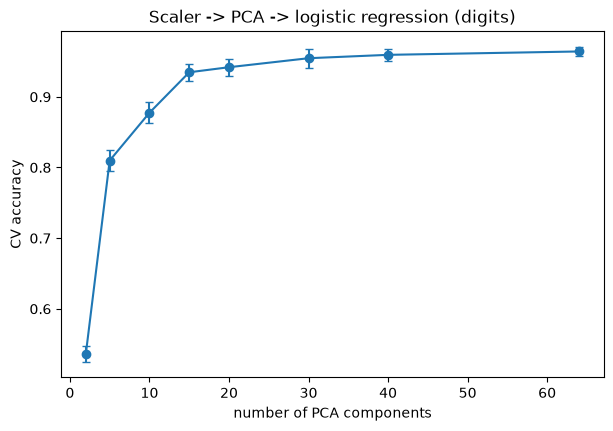

best k: 64   test accuracy: 0.972
 param_pca__n_components  mean_test_score
                       2            0.536
                       5            0.810
                      10            0.877
                      15            0.935
                      20            0.942
                      30            0.955
                      40            0.959
                      64            0.964


In [16]:
pipe = Pipeline([("scaler", StandardScaler()), ("pca", PCA()),
                 ("clf", LogisticRegression(max_iter=3000))])
grid = GridSearchCV(pipe, {"pca__n_components": [2, 5, 10, 15, 20, 30, 40, 64]}, cv=5, n_jobs=-1)
Xtr, Xte, ytr, yte = train_test_split(Xd, yd, test_size=0.3, random_state=0, stratify=yd)
grid.fit(Xtr, ytr)
res = pd.DataFrame(grid.cv_results_)
plt.errorbar(res["param_pca__n_components"].astype(int), res["mean_test_score"], yerr=res["std_test_score"],
             fmt="o-", capsize=3)
plt.xlabel("number of PCA components"); plt.ylabel("CV accuracy"); plt.title("Scaler -> PCA -> logistic regression (digits)")
plt.show()
print("best k:", grid.best_params_["pca__n_components"], "  test accuracy:", round(grid.score(Xte, yte), 3))
print(res[["param_pca__n_components", "mean_test_score"]].round(3).to_string(index=False))

Accuracy rises steeply up to roughly 15–20 components and then plateaus: most of the discriminative information lives in the leading components, so we can compress 64 features to about a third with little loss. Here PCA does not *improve* accuracy (a regularised logistic regression already copes with 64 features) — a common and honest outcome. Its benefits are compression, speed, and noise reduction, which matter more for slower or distance-based models.

In [17]:
# Standardisation matters: breast cancer features have very different scales
Xb, yb = load_breast_cancer(return_X_y=True)
for name, steps in [("PCA(2) without scaling", [PCA(2)]), ("PCA(2) with StandardScaler", [StandardScaler(), PCA(2)])]:
    p = make_pipeline(*steps).fit(Xb)
    evr = p[-1].explained_variance_ratio_
    acc = cross_val_score(make_pipeline(*steps, LogisticRegression(max_iter=3000)), Xb, yb, cv=5).mean()
    print(f"{name:28s}: EVR of 2 PCs = {evr.round(3)}  -> logistic CV acc = {acc:.3f}")

PCA(2) without scaling      : EVR of 2 PCs = [0.982 0.016]  -> logistic CV acc = 0.924
PCA(2) with StandardScaler  : EVR of 2 PCs = [0.443 0.19 ]  -> logistic CV acc = 0.951


Without scaling, the first component is essentially the single largest-scale feature ("worst area", in the thousands), explaining 98% of the "variance" — a unit artefact. With standardisation PCA finds genuinely informative directions.

## 10. Pitfalls & practical tips

- **Centre the data** (PCA assumes it; sklearn does it automatically, `TruncatedSVD` does not — which is desirable for sparse data).
- **Standardise** features with different units before PCA; do not standardise if all features share a meaningful unit (e.g. pixel intensities) and variances carry information.
- **Fit PCA on training data only** (inside a `Pipeline`), exactly like any other preprocessing step.
- **Sign and order ambiguity**: components are defined up to sign (and rotation within equal eigenvalues); do not over-interpret individual loadings, especially when eigenvalues are close.
- **Variance ≠ relevance**: PCA may discard low-variance but discriminative directions. Consider LDA or PLS for supervised reduction.
- **Outliers** strongly affect PCA (it is least squares); consider robust PCA.
- **Use the SVD**, not `eig(X.T @ X)`; for large data use `svd_solver="randomized"` or `IncrementalPCA`.
- **Kernel PCA** is $O(n^2)$ memory: subsample or use Nyström approximations; choose $\gamma$ carefully.
- **t-SNE is for visualisation only**: vary perplexity and seeds, do not interpret cluster sizes or inter-cluster distances, and never cluster on t-SNE coordinates without great caution.

## 11. Exercises

**Exercise 1 (pen & paper — second component).** Show that the direction maximising $\mathbf u^\top S\mathbf u$ subject to $\lVert\mathbf u\rVert=1$ and $\mathbf u\perp\mathbf u_1$ is the eigenvector with the second-largest eigenvalue.

**Exercise 2 (pen & paper — reconstruction error).** Prove $\frac1n\sum_i\lVert\mathbf x_i-U_kU_k^\top\mathbf x_i\rVert^2=\sum_{j>k}\lambda_j$. Then show that PCA scores $Z=XU_k$ are uncorrelated with variances $\lambda_1,\dots,\lambda_k$.

**Exercise 3 (pen & paper — Gram trick).** When $d\gg n$ (e.g. images with more pixels than samples), show that if $\mathbf a$ is an eigenvector of $XX^\top$ ($n\times n$) with eigenvalue $\mu>0$, then $X^\top\mathbf a/\sqrt\mu$ is a unit eigenvector of $X^\top X$ with the same eigenvalue. Relate this to kernel PCA with a linear kernel.

**Exercise 4 (coding — PCA via power iteration).** Implement power iteration with deflation to compute the top 5 principal components of the digits data, and compare with `PCAScratch`. How does the number of iterations needed depend on the eigengap $\lambda_1/\lambda_2$?

**Exercise 5 (coding — classical MDS).** Implement classical MDS: double-centre the squared distance matrix, $B=-\frac12JD^{(2)}J$ with $J=I-\frac1n\mathbf 1\mathbf 1^\top$, and embed with the top eigenvectors scaled by $\sqrt{\text{eigenvalues}}$. Verify that with Euclidean distances the result equals PCA scores up to sign.

**Exercise 6 (coding — PCA vs. supervised relevance).** Construct a 2-class data set where the class difference lies along a *low-variance* direction (e.g. large variance along $x_1$, labels depending on $x_2$ only). Show that `PCA(1)` + logistic regression fails while `LinearDiscriminantAnalysis(n_components=1)` succeeds.

In [18]:
# Exercise 4 — TODO: top-k principal components by power iteration with deflation
def power_iteration_pca(X, k=5, n_iter=500, seed=0):
    # Return (components (k, d), eigenvalues (k,))
    Xc = X - X.mean(0)
    S = Xc.T @ Xc / (len(X) - 1)
    rng_ = np.random.default_rng(seed)
    comps, vals = [], []
    # TODO: for each component: v <- S v / ||S v|| repeatedly; lambda = v^T S v; deflate S <- S - lambda v v^T
    return None

In [19]:
# Exercise 5 — TODO: classical MDS
def classical_mds(D, n_components=2):
    # D: (n, n) matrix of pairwise distances. Return (n, n_components) embedding
    n = len(D)
    J = np.eye(n) - np.ones((n, n)) / n
    # TODO: B = -0.5 * J @ (D ** 2) @ J; eigendecompose; take the top eigenpairs
    pass

## 12. Summary

- High-dimensional spaces are counter-intuitive (volume at the boundary, distance concentration); real data usually live near low-dimensional structure.
- **PCA** projects onto the top eigenvectors of the covariance matrix; it simultaneously **maximises retained variance** and **minimises squared reconstruction error**, with error $=\sum_{j>k}\lambda_j$.
- Compute PCA with the **SVD** of the centred data ($\lambda_j=\sigma_j^2/(n-1)$) for numerical stability.
- Choose $k$ via explained variance, scree plots, or cross-validation of a downstream task; reconstruction with few components compresses and denoises.
- **Whitening** gives identity covariance but amplifies noise in low-variance directions.
- **Kernel PCA** performs PCA in an implicit feature space via the centred kernel matrix; it can unfold non-linear structure like concentric circles.
- **t-SNE / Isomap / MDS** give non-linear 2-D maps; t-SNE preserves local neighbourhoods but not cluster sizes or global distances — use it for visualisation only.
- In supervised pipelines, **scale, then PCA, then model**, all inside cross-validation.

## Further reading

- ESL (Hastie, Tibshirani & Friedman), Ch. 14.5 (principal components, curves and surfaces), 14.8–14.9 (MDS, non-linear dimension reduction).
- ISLR/ISLP (James et al.), Ch. 12.2.
- Bishop PRML, Ch. 12 (continuous latent variables: PCA, PPCA, kernel PCA).
- Murphy PML, Ch. 20 (dimensionality reduction).
- Goodfellow, Bengio & Courville, *Deep Learning*, Ch. 2.12 (PCA) and Ch. 5.11 (curse of dimensionality, manifold learning).
- Géron, *Hands-On Machine Learning*, Ch. 8.
- Pearson, "On lines and planes of closest fit to systems of points in space", 1901; Hotelling, 1933.
- Tipping & Bishop, "Probabilistic principal component analysis", *JRSS-B*, 1999.
- Schölkopf, Smola & Müller, "Nonlinear component analysis as a kernel eigenvalue problem", *Neural Computation*, 1998.
- Tenenbaum, de Silva & Langford, "A global geometric framework for nonlinear dimensionality reduction", *Science*, 2000.
- van der Maaten & Hinton, "Visualizing data using t-SNE", *JMLR*, 2008.
- Wattenberg, Viégas & Johnson, "How to use t-SNE effectively", *Distill*, 2016.
- Halko, Martinsson & Tropp, "Finding structure with randomness", *SIAM Review*, 2011.